# Lab 4: Regression and Classification Evaluation Metrics
## Part 1: KNN Classification on the Breast Cancer Dataset

**Aim:** Use KNN classification on the Breast Cancer dataset and check how well the model works using train-test split, K selection, cross-validation, ROC-AUC, and classification metrics. Also compare these classification metrics with the regression metrics used in Linear Regression (Lab 3).

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset - 569 samples, 30 numerical features, target: 0 = Malignant, 1 = Benign (loaded using `sklearn.datasets`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, roc_auc_score)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)
np.random.seed(42)

## Task 1: Data Preparation


In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [4]:
print("Total missing values:", df.isnull().sum().sum())
print("Number of duplicate rows:", df.duplicated().sum())

Total missing values: 0
Number of duplicate rows: 0


target
1    357
0    212
Name: count, dtype: int64


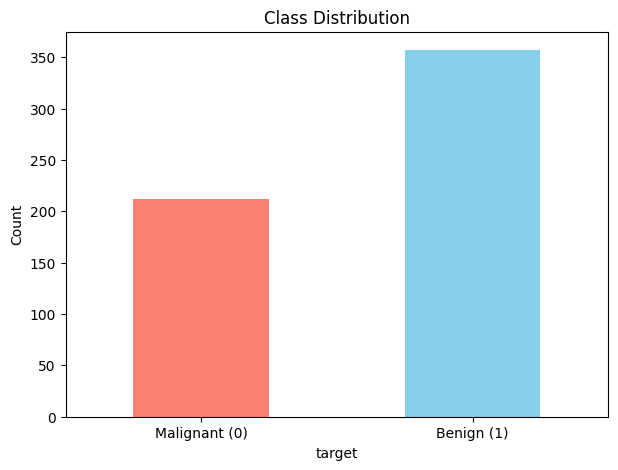

In [5]:
print(df['target'].value_counts())
df['target'].value_counts().sort_index().plot(kind='bar', color=['salmon', 'skyblue'])
plt.xticks([0, 1], ['Malignant (0)', 'Benign (1)'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

### Why Feature Scaling is Important in KNN

KNN decides the class of a point by checking the **distance** to its nearest neighbours.
The features in this dataset are on very different scales. For example, `mean area` can be in the hundreds, while `mean smoothness` is a small decimal. If we do not scale the data, large-value features will affect the distance much more than small-value features. `StandardScaler` fixes this by making all features follow a similar scale. This is very important for distance-based models like KNN.


In [6]:
X = df.drop(columns='target')
y = df['target']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.describe().loc[['mean', 'std']].round(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,...,-0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,...,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001


## Task 2: Train-Test Split Analysis


Split  80:20 -> test size 114, Accuracy: 0.9649
Split  70:30 -> test size 171, Accuracy: 0.9708
Split  90:10 -> test size  57, Accuracy: 0.9825


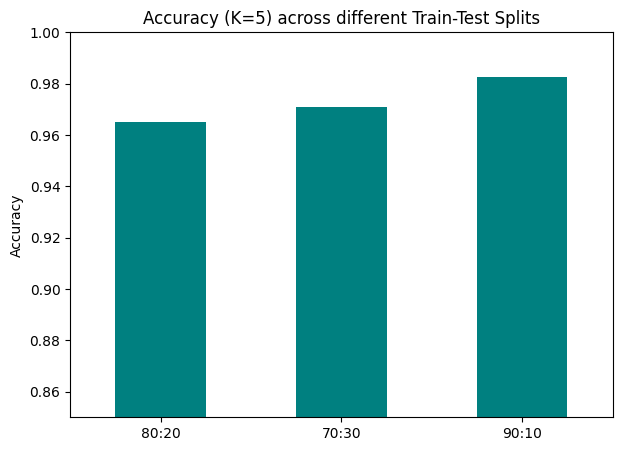

In [7]:
split_ratios = {'80:20': 0.20, '70:30': 0.30, '90:10': 0.10}
split_results = {}

for label, test_size in split_ratios.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, knn.predict(X_te))
    split_results[label] = acc
    print(f"Split {label:>6} -> test size {len(y_te):3d}, Accuracy: {acc:.4f}")

pd.Series(split_results).plot(kind='bar', color='teal')
plt.title('Accuracy (K=5) across different Train-Test Splits')
plt.ylabel('Accuracy')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=0)
plt.show()

**Observation:** A smaller test set like 90:10 gives more data for training, so the model may learn better. But the accuracy is checked on only a few test samples, so the result may be less reliable. A larger test set like 70:30 gives a better estimate of real performance, but leaves less data for training. The 80:20 split gives a good balance, so it is used for the rest of the notebook.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (455, 30)  Test shape: (114, 30)


## Task 3: KNN Model with Heuristic K Selection


### 3.1 Heuristic Method for K Selection


In [9]:
n = X_train.shape[0]
k_heuristic = int(np.sqrt(n))
if k_heuristic % 2 == 0:      # prefer odd K to avoid ties in binary classification
    k_heuristic += 1

print(f"Number of training samples (n): {n}")
print(f"sqrt(n) = {np.sqrt(n):.2f}  ->  Heuristic K (rounded, odd) = {k_heuristic}")

Number of training samples (n): 455
sqrt(n) = 21.33  ->  Heuristic K (rounded, odd) = 21


### 3.2 Model Training


In [10]:
knn_base = KNeighborsClassifier(n_neighbors=k_heuristic)
knn_base.fit(X_train, y_train)
base_acc = accuracy_score(y_test, knn_base.predict(X_test))
print(f"Accuracy with heuristic K={k_heuristic}: {base_acc:.4f}")

Accuracy with heuristic K=21: 0.9561


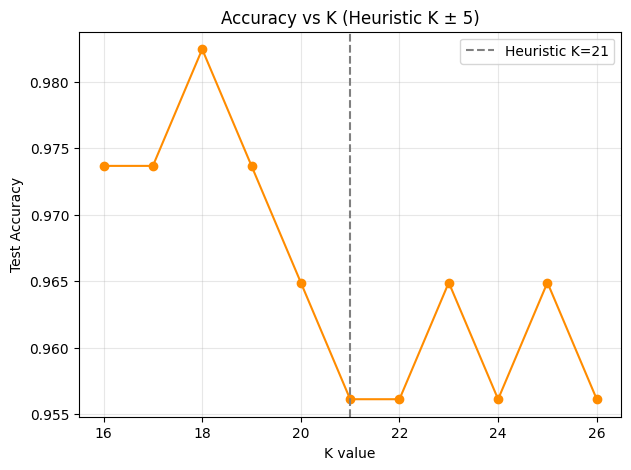

Best K in this range: 18, Accuracy: 0.9825


In [11]:
k_range = range(max(1, k_heuristic - 5), k_heuristic + 6)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, knn.predict(X_test)))

plt.plot(list(k_range), accuracies, marker='o', color='darkorange')
plt.axvline(k_heuristic, color='gray', linestyle='--', label=f'Heuristic K={k_heuristic}')
plt.xlabel('K value')
plt.ylabel('Test Accuracy')
plt.title('Accuracy vs K (Heuristic K \u00b1 5)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_k_local = list(k_range)[int(np.argmax(accuracies))]
print(f"Best K in this range: {best_k_local}, Accuracy: {max(accuracies):.4f}")

### 3.3 Distance Metrics and Decision Boundary Mapping

**Euclidean Distance** - the straight-line distance between two points:

$$d(p,q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}$$

This is the default distance used in KNN. It works well when the features are continuous and properly scaled.

**Manhattan Distance** - the total of the absolute differences in each dimension, like moving through city blocks:

$$d(p,q) = \sum_{i=1}^{n}|p_i - q_i|$$

This distance can work better in high-dimensional data and is usually less affected by outliers than Euclidean distance.

For this dataset, Euclidean distance is the more natural choice because the data has 30 continuous standardized features. Still, Manhattan distance is also worth testing.


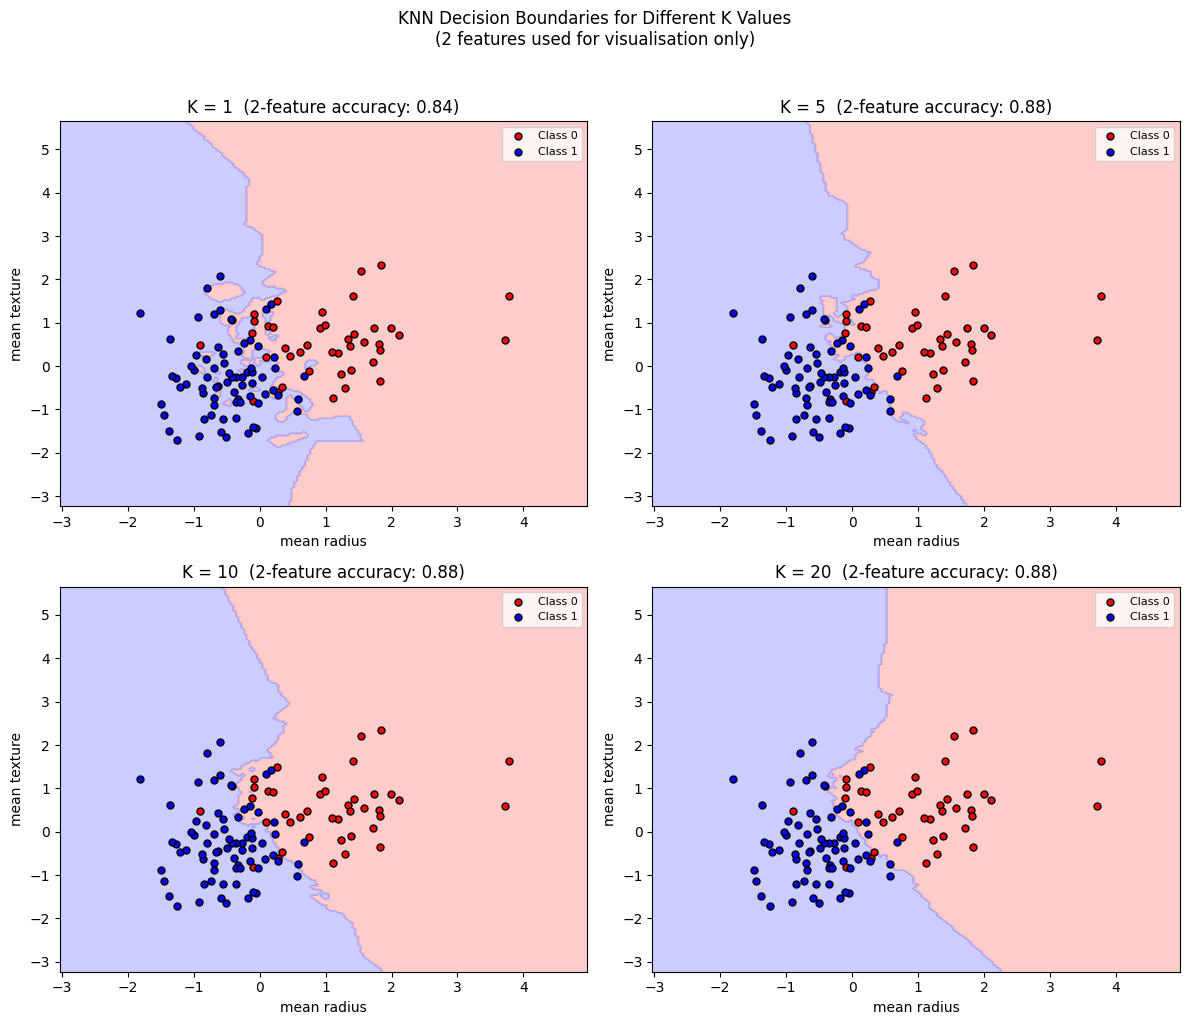

In [12]:
# Decision boundaries can only be visualised in 2D, so we pick two informative features.
feat_x, feat_y = 'mean radius', 'mean texture'
X_vis = X_scaled[[feat_x, feat_y]].values

X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(
    X_vis, y, test_size=0.2, random_state=42, stratify=y)

k_values_vis = [1, 5, 10, 20]
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold = ['red', 'blue']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, k in zip(axes.ravel(), k_values_vis):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_vis_train, y_vis_train)

    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    for cls, color in zip([0, 1], cmap_bold):
        idx = y_vis_test == cls
        ax.scatter(X_vis_test[idx, 0], X_vis_test[idx, 1], c=color, edgecolor='k',
                   s=25, label=f'Class {cls}')
    acc_k = accuracy_score(y_vis_test, clf.predict(X_vis_test))
    ax.set_title(f'K = {k}  (2-feature accuracy: {acc_k:.2f})')
    ax.set_xlabel(feat_x)
    ax.set_ylabel(feat_y)
    ax.legend(fontsize=8)

plt.suptitle('KNN Decision Boundaries for Different K Values\n(2 features used for visualisation only)', y=1.02)
plt.tight_layout()
plt.show()

**Observation:** When K=1, the decision boundary is very uneven and follows noise and outliers closely. This means overfitting. As K increases to 5 and 10, the boundary becomes smoother because the model uses more neighbours to decide. When K becomes too large, like 20, the boundary becomes too smooth and may miss important local patterns. This means underfitting. Also, this plot uses only 2 out of 30 features, so it is only for understanding the boundary shape, not the final model performance.


## Task 4: Cross-Validation


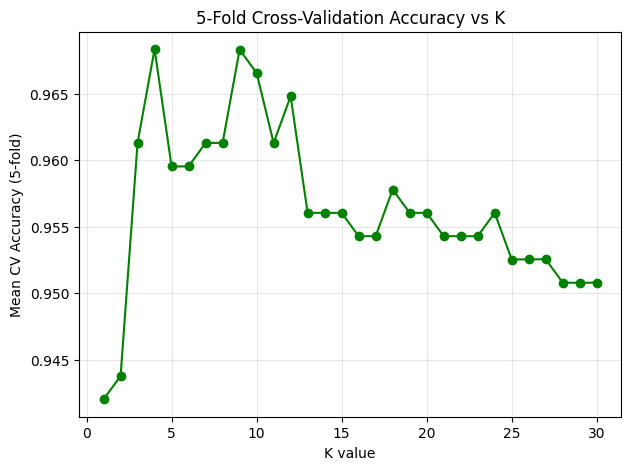

Best K via 5-fold CV: 4, Mean CV Accuracy: 0.9683


In [13]:
cv_k_range = range(1, 31)
cv_means = []
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for k in cv_k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=kfold, scoring='accuracy')
    cv_means.append(scores.mean())

plt.plot(list(cv_k_range), cv_means, marker='o', color='green')
plt.xlabel('K value')
plt.ylabel('Mean CV Accuracy (5-fold)')
plt.title('5-Fold Cross-Validation Accuracy vs K')
plt.grid(alpha=0.3)
plt.show()

best_k_cv = list(cv_k_range)[int(np.argmax(cv_means))]
print(f"Best K via 5-fold CV: {best_k_cv}, Mean CV Accuracy: {max(cv_means):.4f}")

In [14]:
print(f"Heuristic K                     : {k_heuristic:2d}  -> Single split accuracy : {base_acc:.4f}")
print(f"Best K (train-test K\u00b15 search) : {best_k_local:2d}  -> Single split accuracy : {max(accuracies):.4f}")
print(f"Best K (5-fold CV)               : {best_k_cv:2d}  -> Mean CV accuracy       : {max(cv_means):.4f}")

final_k = best_k_cv
print(f"\nFinal chosen K (heuristic + validation evidence combined): {final_k}")

Heuristic K                     : 21  -> Single split accuracy : 0.9561
Best K (train-test K±5 search) : 18  -> Single split accuracy : 0.9825
Best K (5-fold CV)               :  4  -> Mean CV accuracy       : 0.9683

Final chosen K (heuristic + validation evidence combined): 4


**Why cross-validation is more reliable than a single train-test split:** A single split gives only one accuracy value, and that value depends on which samples ended up in the test set. In K-fold cross-validation, every sample gets a chance to be in the test set across different folds. The final score is the average of all folds, so it gives a more stable and trustworthy estimate of model performance.


## Task 5: Classification Evaluation (Final Model)


In [15]:
final_model = KNeighborsClassifier(n_neighbors=final_k)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Accuracy : 0.9386
Precision: 0.9710
Recall   : 0.9306
F1 Score : 0.9504
ROC-AUC  : 0.9807


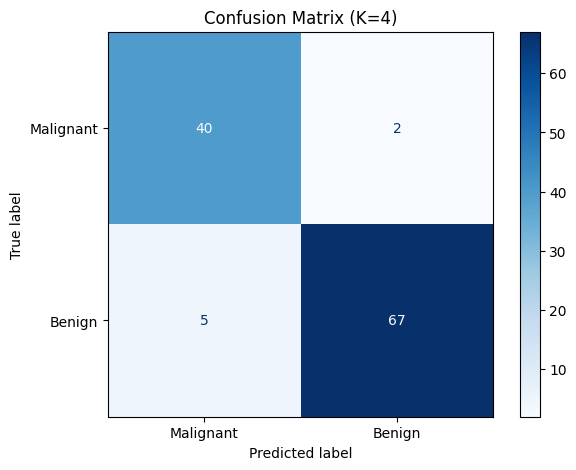

In [16]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (K={final_k})')
plt.show()

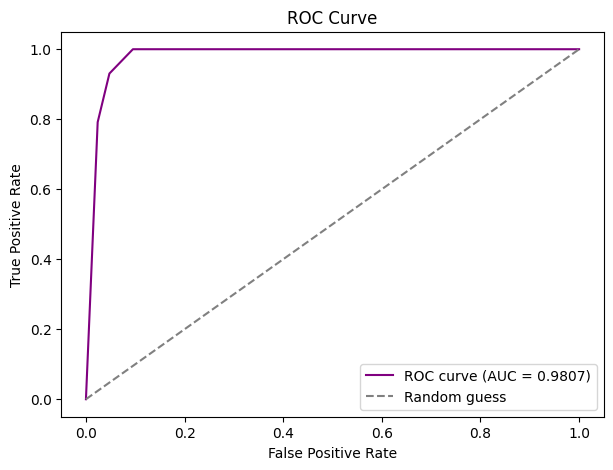

In [17]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.4f})', color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Task 6: Comparative Study with Regression (Lab 3 Integration)


Lab 3 used Simple Linear Regression on the **Department Awareness Survey** dataset to predict **GPA** using two separate input variables:
- **Experiment 1:** CIA % -> GPA
- **Experiment 2:** Attendance % -> GPA

The values shown below are taken from your Lab 3 notebook output, so this comparison uses your actual earlier results.


In [18]:
# Results copied directly from Lab 3 (Department Awareness Survey - GPA regression)

lab3_results = {
    'Experiment 1: CIA % \u2192 GPA': {
        'slope': 0.0700, 'intercept': 0.7864, 'r2': 0.0074, 'mse': 169.2125
    },
    'Experiment 2: Attendance % \u2192 GPA': {
        'slope': -0.8363, 'intercept': 83.7276, 'r2': 0.0830, 'mse': 167.5555
    }
}

for exp, vals in lab3_results.items():
    rmse = np.sqrt(vals['mse'])
    vals['rmse'] = rmse
    print(f"{exp}")
    print(f"  Slope     : {vals['slope']:.4f}")
    print(f"  Intercept : {vals['intercept']:.4f}")
    print(f"  R2 Score  : {vals['r2']:.4f}")
    print(f"  MSE       : {vals['mse']:.4f}")
    print(f"  RMSE      : {rmse:.4f}")
    print()

Experiment 1: CIA % → GPA
  Slope     : 0.0700
  Intercept : 0.7864
  R2 Score  : 0.0074
  MSE       : 169.2125
  RMSE      : 13.0082

Experiment 2: Attendance % → GPA
  Slope     : -0.8363
  Intercept : 83.7276
  R2 Score  : 0.0830
  MSE       : 167.5555
  RMSE      : 12.9443



In [19]:
comparison = pd.DataFrame({
    'Metric': ['R\u00b2 Score', 'MSE', 'RMSE', 'MAE'],
    'Lab 3 - Exp 1 (CIA % \u2192 GPA)': [
        f"{lab3_results['Experiment 1: CIA % \u2192 GPA']['r2']:.4f}",
        f"{lab3_results['Experiment 1: CIA % \u2192 GPA']['mse']:.4f}",
        f"{lab3_results['Experiment 1: CIA % \u2192 GPA']['rmse']:.4f}",
        'not computed in Lab 3'
    ],
    'Lab 3 - Exp 2 (Attendance % \u2192 GPA)': [
        f"{lab3_results['Experiment 2: Attendance % \u2192 GPA']['r2']:.4f}",
        f"{lab3_results['Experiment 2: Attendance % \u2192 GPA']['mse']:.4f}",
        f"{lab3_results['Experiment 2: Attendance % \u2192 GPA']['rmse']:.4f}",
        'not computed in Lab 3'
    ],
    'Analogous Classification Metric (Lab 4 - KNN)': ['Accuracy', 'Confusion Matrix (FP/FN counts)', 'F1 Score', 'Confusion Matrix (FP/FN counts)'],
    'Lab 4 Value': [f"{acc:.4f}", 'see confusion matrix above', f"{f1:.4f}", 'see confusion matrix above']
})
comparison

,Metric,Lab 3 - Exp 1 (CIA % → GPA),Lab 3 - Exp 2 (Attendance % → GPA),Analogous Classification Metric (Lab 4 - KNN),Lab 4 Value
0,R² Score,0.0074,0.0830,Accuracy,0.9386
1,MSE,169.2125,167.5555,Confusion Matrix (FP/FN counts),see confusion matrix above
2,RMSE,13.0082,12.9443,F1 Score,0.9504
3,MAE,not computed in Lab 3,not computed in Lab 3,Confusion Matrix (FP/FN counts),see confusion matrix above


**Reading these numbers together:** In Lab 3, both regression models have very low R-squared values and fairly high error values, which means CIA % and Attendance % alone are not strong linear predictors of GPA in that dataset. In Lab 4, the KNN classifier gives much better accuracy and F1 score on the Breast Cancer dataset. But this does not mean classification is always better than regression. The two labs use different datasets and different problems. The main purpose here is to understand what each metric measures.


### Error-based vs. Decision-based Evaluation

- **Regression (error-based):** Regression predicts continuous values. So we measure how far the prediction is from the real value using metrics like MAE, MSE, RMSE, and R-squared.
- **Classification (decision-based):** Classification predicts class labels. So we measure whether the class prediction is correct, and also what type of mistake happened.

**R-squared vs. Accuracy** - Both are summary scores where higher is better. But R-squared shows how much variation in a continuous target is explained by the model, while accuracy shows how many class labels were predicted correctly.

**RMSE vs. F1 Score** - RMSE measures the size of prediction errors in regression. F1 score combines precision and recall into one value for classification, especially when both kinds of errors matter.

**MAE vs. Confusion Matrix** - MAE gives one average error value. A confusion matrix shows the exact types of classification results: TP, TN, FP, and FN.

**Continuous vs. classification evaluation logic** - In regression, the output is continuous, so we care about how far the prediction is from the true value. In classification, the output is a category, so we care more about whether the prediction is correct and what kind of wrong prediction was made.


### Inference

- **Regression metrics (MAE, MSE, RMSE, R-squared)** show how large the prediction error is for continuous values.
- **Classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC)** show how correctly the model predicts classes and what kinds of mistakes it makes.
- **Accuracy alone is not enough in medical diagnosis** because a model can still miss dangerous malignant cases and yet show a high accuracy.
- **Recall and ROC-AUC are more important in healthcare** because recall shows how many actual malignant cases were correctly found, and ROC-AUC shows how well the model separates the two classes across many thresholds.
- **Overall**, regression metrics and classification metrics answer different questions, so we choose them based on whether the target is continuous or categorical.


## Task 7: Analytical Questions


**1. Why is KNN called a lazy learning algorithm?**
KNN does not build a model during training. It simply stores the training data and does the main work only when a new point needs to be predicted.

**2. Why is feature scaling required in KNN?**
KNN uses distance to make predictions. If one feature has much larger values than others, it will dominate the distance calculation. Scaling makes all features contribute more fairly.

**3. Explain heuristic K selection using the sqrt(n) rule.**
A common rule is to choose K around sqrt(n), where n is the number of training samples. It gives a simple starting point. A very small K may overfit, and a very large K may underfit. For binary classification, an odd K is usually chosen to avoid ties.

**4. Why is cross-validation more reliable than a single train-test split?**
A single split can give a result that depends too much on one random division of the data. Cross-validation checks the model on many different splits and averages the results, so the final score is more stable.

**5. How does K affect the bias-variance trade-off?**
A small K gives low bias but high variance, so the model may overfit. A large K gives high bias but low variance, so the model may underfit. A good K balances both.

**6. Why is recall more important than accuracy in cancer prediction?**
In cancer prediction, missing a real malignant case is very serious. Recall measures how many actual malignant cases are correctly found, so it is more important than just overall accuracy.

**7. What is the limitation of very large K values?**
A very large K makes the decision boundary too smooth, so the model may miss useful local patterns and underfit. In extreme cases, it may mostly predict the majority class. It also takes more time during prediction because more neighbours must be checked.


## Conclusion

- **Optimal K:** The sqrt(n) rule was used as a starting point, and the final K was chosen after comparing train-test accuracy with 5-fold cross-validation results.
- **Effect of train-test split variation:** Accuracy changed slightly across the 80:20, 70:30, and 90:10 splits. More training data can help the model learn better, while a larger test set gives a more reliable performance estimate.
- **Model performance:** The final KNN model was checked using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC. See Task 5 for the exact results.
- **Regression vs. classification evaluation:** Regression metrics measure continuous prediction error, while classification metrics measure how well the model makes class decisions.
- **Insights from Lab 3 vs. this lab:** Both labs follow a similar machine learning workflow, but the evaluation metrics must match the type of target variable.
